In [268]:
# imports
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
from finvizfinance.quote import finvizfinance

import warnings
warnings.filterwarnings("ignore")

import os

In [269]:
# source directories toggle
use_rankings_main = False          # ..\14_stocks_analysis\00_rankings
use_rankings_sector = True        # ..\14_stocks_analysis\01_rankings_sector

dir_options = [
    (use_rankings_main, r"..\14_stocks_analysis\00_rankings"),
    (use_rankings_sector, r"..\14_stocks_analysis\01_rankings_sector"),
]
selected_dirs = [path for enabled, path in dir_options if enabled]

if not selected_dirs:
    raise ValueError('Enable at least one source directory in Cell 2.')

missing_dirs = [path for path in selected_dirs if not os.path.isdir(path)]
if missing_dirs:
    raise FileNotFoundError(f'Directories do not exist: {missing_dirs}')

print('Using data directories:')
for path in selected_dirs:
    print(f' - {path}')

Using data directories:
 - ..\14_stocks_analysis\01_rankings_sector


In [270]:
# concatenate all tabular files from selected directories into a single dataframe
files = []

for dir_path in selected_dirs:
    dir_files = [
        file for file in os.listdir(dir_path)
        if file.lower().endswith(('.csv', '.xlsx', '.xls'))
    ]
    files.extend([(dir_path, file) for file in dir_files])

if not files:
    raise ValueError(f'No CSV/XLSX/XLS files found in selected directories: {selected_dirs}')

def load_table(dir_path, file_name):
    file_path = os.path.join(dir_path, file_name)
    if file_name.lower().endswith('.csv'):
        return pd.read_csv(file_path)
    return pd.read_excel(file_path)

# file name format like 2603, 2602... first two digits year, last two month
def extract_date(file_name):
    year = int(file_name[:2]) + 2000
    month = int(file_name[2:4])
    return pd.Timestamp(year=year, month=month, day=1)

df = pd.concat(
    [
        load_table(dir_path, file_name).assign(
            date=extract_date(file_name),
            source_dir=os.path.basename(dir_path),
        )
        for dir_path, file_name in sorted(files, key=lambda x: (x[0], x[1]))
    ],
    ignore_index=True,
)

# lowercase column names
df.columns = df.columns.str.lower()

# replace spaces with underscore in column names
df.columns = df.columns.str.replace(' ', '_')

df.head()

,unnamed:_0,symbol,stock,market_cap,unnamed:_4,fair_value_(%),z-score,f-score,m-score,value_generation,date,source_dir,country,unnamed:_9
0,1.0,Sezzle Inc.,Sezzle Inc.,2.02B,Sezzle Inc.,+181.69,8.97,8.0,-3.46,Robust,2026-04-01,01_rankings_sector,NaN,NaN
1,NaN,SEZL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-01,01_rankings_sector,NaN,NaN
2,2.0,"PayPal Holdings, Inc.","PayPal Holdings, Inc.",43.39B,"PayPal Holdings, Inc.",+82.82,1.99,8.0,-2.54,Robust,2026-04-01,01_rankings_sector,NaN,NaN
3,NaN,PYPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-04-01,01_rankings_sector,NaN,NaN
4,3.0,"Virtus Investment Partners, Inc.","Virtus Investment Partners, Inc.",938.65M,"Virtus Investment Partners, Inc.",+65.71,0.75,6.0,-2.71,Robust,2026-04-01,01_rankings_sector,NaN,NaN


In [271]:
# print len of dataframe
print(f"Dataframe length: {len(df)}")

Dataframe length: 400


In [272]:
# create a copy of symbol column named 'symbol_copy'
df['symbol_copy'] = df['symbol']

In [273]:
# the series in df.symbol_copy, should be shifted backwards by 1 row, to align with the stock name in the same row
df['symbol_copy'] = df['symbol_copy'].shift(-1)

In [274]:
# drop nan in df.unnamed:_0
df = df.dropna(subset=['unnamed:_0'])

In [275]:
# drop columns 'unnamed: 0', 'symbol' (ignore if already removed)
df = df.drop(columns=['unnamed:_0', 'symbol'], errors='ignore')

# rename column 'symbol_copy' to 'symbol' if needed
if 'symbol_copy' in df.columns and 'symbol' not in df.columns:
    df = df.rename(columns={'symbol_copy': 'symbol'})

# columns order
selected_cols = [
    'date', 'symbol', 'stock', 'market_cap', 'price',
    'fair_value_(%)', 'z-score', 'f-score', 'm-score', 'value_generation'
]

# if 'price' is missing, continue without it
if 'price' not in df.columns:
    selected_cols = [c for c in selected_cols if c != 'price']

# keep only columns that exist
selected_cols = [c for c in selected_cols if c in df.columns]
df = df[selected_cols]

In [276]:
df.columns

Index(['date', 'symbol', 'stock', 'market_cap', 'fair_value_(%)', 'z-score',
       'f-score', 'm-score', 'value_generation'],
      dtype='object')

In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 0 to 298
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              150 non-null    datetime64[us]
 1   symbol            150 non-null    object        
 2   stock             150 non-null    object        
 3   market_cap        150 non-null    object        
 4   fair_value_(%)    150 non-null    object        
 5   z-score           150 non-null    object        
 6   f-score           150 non-null    object        
 7   m-score           150 non-null    float64       
 8   value_generation  150 non-null    object        
dtypes: datetime64[us](1), float64(1), object(7)
memory usage: 11.7+ KB


In [278]:
# create a copy of the dataframe
df_copy = df.copy()

# keep only date, symbol columns
df_copy = df_copy[['date', 'symbol']]

# group by symbol and count the number of occurrences of each symbol
symbol_counts = df_copy.groupby('symbol').size().reset_index(name='count')

# sort the dataframe by count in descending order
symbol_counts = symbol_counts.sort_values(by='count', ascending=False)

# display the top 10 symbols with the most occurrences
print(symbol_counts.head(10))

    symbol  count
0  1082.KL      1
1  1295.KL      1
2  1929.HK      1
3  2313.HK      1
4   3402.T      1
5   4324.T      1
6   4689.T      1
7   4751.T      1
8  6012.KL      1
9  6014.SR      1


In [279]:
# drop duplicates in df.symbol, keep last occurrence
df = df.drop_duplicates(subset='symbol', keep='last')

# merge df with symbol_counts on symbol, keeping only rows that are in df
df = df.merge(symbol_counts, on='symbol', how='inner')

# sort df by count in descending order
df = df.sort_values(by='count', ascending=False)

df.head(10)

,date,symbol,stock,market_cap,fair_value_(%),z-score,f-score,m-score,value_generation,count
0,2026-04-01,SEZL,Sezzle Inc.,2.02B,+181.69,8.97,8.0,-3.46,Robust,1
1,2026-04-01,PYPL,"PayPal Holdings, Inc.",43.39B,+82.82,1.99,8.0,-2.54,Robust,1
2,2026-04-01,VRTS,"Virtus Investment Partners, Inc.",938.65M,+65.71,0.75,6.0,-2.71,Robust,1
3,2026-04-01,NPB,"Northpointe Bancshares, Inc.",270.37M,+51.77,0.08,--,-3.51,Robust,1
4,2026-04-01,GCBC,"Greene County Bancorp, Inc.",396.73M,+49.61,0.9,8.0,83.31,Robust,1
5,2026-04-01,RMBI,"Richmond Mutual Bancorporation, Inc.",134.20M,+44.75,0.17,6.0,-3.24,Robust,1
6,2026-04-01,SLM,SLM Corporation,4.45B,+40.20,0.7,8.0,-3.01,Robust,1
7,2026-04-01,TCBI,"Texas Capital Bancshares, Inc.",4.54B,+37.36,0.47,9.0,-3.30,Robust,1
8,2026-04-01,NNI,"Nelnet, Inc.",4.81B,+57.30,0.13,7.0,-2.87,Robust,1
9,2026-04-01,NECB,"Northeast Community Bancorp, Inc.",335.64M,+30.26,0.3,6.0,-2.67,Robust,1


In [280]:
# market cap column is object. We need to convert it to numeric, removing any non-numeric characters ("T" indicating trillions, 
# "B", indicating billions, "M" indicating millions, "K" indicating thousands)
# These characters are at the end of the string, so we can use str.replace to remove them and then convert to numeric
# They will be added in a new column named 'market cap um'

# take last character of market cap column and add a new column 'market_cap_um' with the value of the last character
df['market_cap_um'] = df['market_cap'].str[-1]

# replace 'T', 'B', 'M', 'K' with "" in market cap column and convert to numeric
df['market_cap'] = df['market_cap'].str.replace(r'[TBMK]', '', regex=True).astype(float)


In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              150 non-null    datetime64[us]
 1   symbol            150 non-null    object        
 2   stock             150 non-null    object        
 3   market_cap        150 non-null    float64       
 4   fair_value_(%)    150 non-null    object        
 5   z-score           150 non-null    object        
 6   f-score           150 non-null    object        
 7   m-score           150 non-null    float64       
 8   value_generation  150 non-null    object        
 9   count             150 non-null    int64         
 10  market_cap_um     150 non-null    object        
dtypes: datetime64[us](1), float64(2), int64(1), object(7)
memory usage: 13.0+ KB


In [282]:
# if market cap um is M, market cap / 1000, if market cap um is T, market cap * 1000, if market cap um is B, market cap / 1
def convert_market_cap(row):
    if row['market_cap_um'] == 'M':
        return row['market_cap'] / 1000
    elif row['market_cap_um'] == 'T':
        return row['market_cap'] * 1000
    elif row['market_cap_um'] == 'B':
        return row['market_cap']
    elif row['market_cap_um'] == 'K':
        return row['market_cap'] / 1000
    else:
        return row['market_cap']

# apply the function to the dataframe and create a new column 'market_cap_converted'
df['market_cap_converted'] = df.apply(convert_market_cap, axis=1)

In [283]:
# drop market cap	
df = df.drop(columns=['market_cap'])

# rename market cap converted to market cap
df = df.rename(columns={'market_cap_converted': 'market_cap'})

# # columns order 'date', 'symbol', 'stock', 'price', 'fair value (%)', 'z-score', 'f-score', 'm-score', 'value generation', 'market cap um', 'market cap'
# df = df[['date', 'symbol', 'stock', 'price', 'fair_value_(%)', 'z-score', 
# 'f-score', 'm-score', 'value_generation', 'market_cap_um', 'market_cap', 'count']]

desired_cols = ['date', 'symbol', 'stock', 'price', 'fair_value_(%)', 'z-score',
'f-score', 'm-score', 'value_generation', 'market_cap_um', 'market_cap', 'count']
df = df[[c for c in desired_cols if c in df.columns]]


In [284]:
# --- market cap filter ---
# drop all rows where market cap um is M and K
df = df[~df['market_cap_um'].isin(['M', 'K'])]

# drop all rows where market cap um is B and market cap is less than 10
df = df[~((df['market_cap_um'] == 'B') & (df['market_cap'] < 10))]

# rename df.market_cap to market_cap_(B)
df = df.rename(columns={'market_cap': 'market_cap_(B)'})

# drop market_cap_um
df = df.drop(columns=['market_cap_um'])

In [285]:
# add currency column according to the stock exchange where the stock is listed. Need to identify currency based on df.symbol 
# ends with:
# .MI -> EUR
# .DE -> EUR
# .PA -> EUR
# .L -> GBP
# .T -> JPY
# .AX -> AUD
# .SR -> SAR
# .HK -> HKD
# .TO -> CAD
# .NZ -> NZD
# .KL -> MYR
# .MX -> MXN
# if df.symbol does not contain ".", add USD as currency
# if none of the above conditions are met, currency 
def identify_currency(symbol):
    if symbol.endswith('.MI') or symbol.endswith('.DE') or symbol.endswith('.PA'):
        return 'EUR'
    elif symbol.endswith('.L'):
        return 'GBP'
    elif symbol.endswith('.T'):
        return 'JPY'
    elif symbol.endswith('.AX'):
        return 'AUD'
    elif symbol.endswith('.SR'):
        return 'SAR'
    elif symbol.endswith('.HK'):
        return 'HKD'
    elif symbol.endswith('.TO'):
        return 'CAD'
    elif symbol.endswith('.NZ'):
        return 'NZD'
    elif symbol.endswith('.KL'):
        return 'MYR'
    elif symbol.endswith('.MX'):
        return 'MXN'
    elif '.' not in symbol:
        return 'USD'
    else:
        return 'Unknown'
    
# apply the function to the dataframe and create a new column 'currency'
df['currency'] = df['symbol'].apply(identify_currency)

In [286]:
# print Unknown symbols in currency column
print(df[df['currency'] == 'Unknown']['symbol'])

18            A5G.IR
19            DNB.OL
97            AMS.MC
112           REN.AS
114           PRX.AS
128    BHARTIARTL.NS
143           UMG.AS
Name: symbol, dtype: object


In [287]:
# --- currency filter ---
# keep only EUR and USD stocks
df = df[df['currency'].isin(['EUR', 'USD'])]

In [288]:
# --- solidity filter ---
# convert z-score, f-score, m-score to numeric
df['z-score'] = pd.to_numeric(df['z-score'], errors='coerce')
df['f-score'] = pd.to_numeric(df['f-score'], errors='coerce')
df['m-score'] = pd.to_numeric(df['m-score'], errors='coerce')

# drop all rows where z-score is less than 1.81
# drop all rows where f-score is less than 3
# drop all rows where m-score is higher than -1.78
df = df[~((df['z-score'] < 1.81) | (df['f-score'] < 3) | (df['m-score'] > -1.78))]

In [289]:
# --- fair_value_(%) filter ---
# convert fair_value_(%) to numeric
df['fair_value_(%)'] = pd.to_numeric(df['fair_value_(%)'], errors='coerce')

# keep only rows where fair_value_(%) is higher than 0
df = df[df['fair_value_(%)'] > 0]

In [290]:
# list of tickers in the dataframe
tickers = df['symbol'].tolist()

In [ ]:
# TODO: when we have new data, below code can be used to update the fundamentals cache, 
# by downloading fundamentals for all tickers in the dataframe, 
# keeping only the keys in keys_to_keep, prefixing the columns with "fv_", 
# and writing the cache to a CSV file. This way we can keep the fundamentals cache 
# updated with the latest tickers in the dataframe, 
# without having to download fundamentals for all tickers every time we run the notebook.

# batch fundamentals download for all tickers (keeps only keys_to_keep, prefixes columns, writes cache CSV)
from pathlib import Path
import re
import time

keys_to_keep = ['Company', 'Sector', 'Industry', 'P/E', 'EPS (ttm)',
'Perf Week', 'Forward P/E', 'Perf Month',
'Short Float', 'Perf Quarter', 'P/S', 'EPS this Y',
'Short Ratio', 'Perf Half Y', 'P/B', 'ROA', 'Perf YTD', 'P/C',
'ROE', '52W High', 'Perf Year', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.',
'EV/EBITDA', 'Sales past 3/5Y', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM',
'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom',
'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume',
'Prev Close', 'LT Debt/Eq', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change']

def normalize_fundament_key(key):
    clean_key = re.sub(r'[^0-9a-zA-Z]+', '_', key).strip('_').lower()
    return f'fv_{clean_key}'

key_to_col = {key: normalize_fundament_key(key) for key in keys_to_keep}
fundamentals_rows = []
failed_tickers = []

for t in tickers:
    try:
        stock_obj = finvizfinance(t)
        stock_fundament = stock_obj.ticker_fundament()
        row = {'symbol': t}
        for key in keys_to_keep:
            row[key_to_col[key]] = stock_fundament.get(key)
        fundamentals_rows.append(row)
    except Exception:
        failed_tickers.append(t)
    time.sleep(0.25)

fundamentals_df = pd.DataFrame(fundamentals_rows)

fundamentals_cache_path = Path('14_stocks_analysis/fundamentals_cache.csv')
fundamentals_cache_path.parent.mkdir(parents=True, exist_ok=True)
fundamentals_df.to_csv(fundamentals_cache_path, index=False)

print(f'Fundamentals downloaded for {len(fundamentals_df)} tickers')
print(f'Fundamentals cache saved to: {fundamentals_cache_path}')

# failed tickers report
if failed_tickers:
    print('Failed tickers:')
    print(failed_tickers)
else:
    print('No failed tickers.')

In [ ]:
# load fundamentals from cache CSV (for tests, avoids repeated API calls)
from pathlib import Path

fundamentals_cache_path = Path('14_stocks_analysis/fundamentals_cache.csv')
fundamentals_df = pd.read_csv(fundamentals_cache_path)

print(f'Loaded fundamentals cache: {fundamentals_cache_path}')
print(f'Rows: {len(fundamentals_df)}')

fundamentals_df.head()

Loaded fundamentals cache: 14_stocks_analysis\fundamentals_cache.csv
Rows: 10


,symbol,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_perf_month,fv_short_float,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,PYPL,PayPal Holdings Inc,Financial,Credit Services,8.36,5.41,-0.22%,7.83,-0.72%,5.00%,...,45.98,0.52,-25.97%,23.95M,45.24,"Jul 06, 2015",-4.43% -1.28%,\n\n,"13,085,430",-1.61%
1,MRSH,Marsh,Financial,Insurance Brokers,19.96,8.42,-3.70%,14.87,-3.35%,1.17%,...,173.14,1.31,-11.90%,3.16M,168.15,"Feb 19, 1968",7.43% 0.60%,\n\n,"2,970,210",-2.88%
2,MSCI,MSCI Inc,Financial,Financial Data & Stock Exchanges,34.20,15.69,-1.52%,24.43,-1.93%,1.69%,...,545.88,-,-4.69%,632.57K,536.48,"Nov 15, 2007",1.37% 0.01%,\n\n,"534,185",-1.72%
3,CCK,"Crown Holdings, Inc",Consumer Cyclical,Packaging & Containers,16.78,6.38,4.08%,12.09,1.96%,4.53%,...,107.84,1.85,5.25%,1.15M,106.95,"Dec 18, 1984",2.07% 4.48%,\n\n,"1,019,623",-0.83%
4,DRI,"Darden Restaurants, Inc",Consumer Cyclical,Restaurants,20.36,9.45,-2.01%,16.90,-5.43%,4.54%,...,196.34,3.61,-2.82%,1.49M,192.39,"May 09, 1995",0.22% 0.32%,\n\n,"1,235,435",-2.01%


In [ ]:
# merge fundamentals into df on symbol
df = df.merge(fundamentals_df, on='symbol', how='left')

print(f'Merged dataframe rows: {len(df)}')
print(f'Columns after merge: {len(df.columns)}')

df.head()

Merged dataframe rows: 10
Columns after merge: 74


,date,symbol,stock,fair_value_(%),z-score,f-score,m-score,value_generation,market_cap_(B),count,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,2026-04-01,PYPL,"PayPal Holdings, Inc.",82.82,1.99,8.0,-2.54,Robust,43.39,1,...,45.98,0.52,-25.97%,23.95M,45.24,"Jul 06, 2015",-4.43% -1.28%,\n\n,"13,085,430",-1.61%
1,2026-04-01,MRSH,"Marsh & McLennan Companies, Inc.",32.86,2.76,6.0,-2.57,Robust,81.89,1,...,173.14,1.31,-11.90%,3.16M,168.15,"Feb 19, 1968",7.43% 0.60%,\n\n,"2,970,210",-2.88%
2,2026-04-01,MSCI,MSCI Inc.,30.93,5.99,7.0,-3.46,Robust,41.04,1,...,545.88,-,-4.69%,632.57K,536.48,"Nov 15, 2007",1.37% 0.01%,\n\n,"534,185",-1.72%
3,2026-04-01,CCK,"Crown Holdings, Inc.",37.71,2.29,7.0,-2.14,Robust,12.32,1,...,107.84,1.85,5.25%,1.15M,106.95,"Dec 18, 1984",2.07% 4.48%,\n\n,"1,019,623",-0.83%
4,2026-04-01,DRI,"Darden Restaurants, Inc.",15.86,2.57,7.0,-3.19,Robust,22.30,1,...,196.34,3.61,-2.82%,1.49M,192.39,"May 09, 1995",0.22% 0.32%,\n\n,"1,235,435",-2.01%


In [ ]:
# quick check: tickers used in batch download
tickers[:10]

['PYPL', 'MRSH', 'MSCI', 'CCK', 'DRI', 'TSCO', 'LEN', 'NYT', 'DIS', 'RDDT']

In [ ]:
# quick check: cached fundamentals columns (prefixed with fv_)
fundamentals_df.columns.tolist()[:20]

['symbol',
 'fv_company',
 'fv_sector',
 'fv_industry',
 'fv_p_e',
 'fv_eps_ttm',
 'fv_perf_week',
 'fv_forward_p_e',
 'fv_perf_month',
 'fv_short_float',
 'fv_perf_quarter',
 'fv_p_s',
 'fv_eps_this_y',
 'fv_short_ratio',
 'fv_perf_half_y',
 'fv_p_b',
 'fv_roa',
 'fv_perf_ytd',
 'fv_p_c',
 'fv_roe']

In [ ]:
# preview merged fundamentals for first rows
df.filter(regex='^fv_').head()

,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_perf_month,fv_short_float,fv_perf_quarter,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,PayPal Holdings Inc,Financial,Credit Services,8.36,5.41,-0.22%,7.83,-0.72%,5.00%,-22.36%,...,45.98,0.52,-25.97%,23.95M,45.24,"Jul 06, 2015",-4.43% -1.28%,\n\n,"13,085,430",-1.61%
1,Marsh,Financial,Insurance Brokers,19.96,8.42,-3.70%,14.87,-3.35%,1.17%,-10.03%,...,173.14,1.31,-11.90%,3.16M,168.15,"Feb 19, 1968",7.43% 0.60%,\n\n,"2,970,210",-2.88%
2,MSCI Inc,Financial,Financial Data & Stock Exchanges,34.20,15.69,-1.52%,24.43,-1.93%,1.69%,-7.72%,...,545.88,-,-4.69%,632.57K,536.48,"Nov 15, 2007",1.37% 0.01%,\n\n,"534,185",-1.72%
3,"Crown Holdings, Inc",Consumer Cyclical,Packaging & Containers,16.78,6.38,4.08%,12.09,1.96%,4.53%,3.28%,...,107.84,1.85,5.25%,1.15M,106.95,"Dec 18, 1984",2.07% 4.48%,\n\n,"1,019,623",-0.83%
4,"Darden Restaurants, Inc",Consumer Cyclical,Restaurants,20.36,9.45,-2.01%,16.90,-5.43%,4.54%,-4.99%,...,196.34,3.61,-2.82%,1.49M,192.39,"May 09, 1995",0.22% 0.32%,\n\n,"1,235,435",-2.01%


In [ ]:
# count how many symbols did not receive fundamentals
missing_fv = df['fv_company'].isna().sum() if 'fv_company' in df.columns else None
print('Symbols with missing fundamentals:', missing_fv)

Symbols with missing fundamentals: 0


In [ ]:
# # print failed tickers again (separate output cell)
# print(failed_tickers)

In [ ]:
# show first 3 rows from fundamentals cache dataframe
fundamentals_df.head(3)

,symbol,fv_company,fv_sector,fv_industry,fv_p_e,fv_eps_ttm,fv_perf_week,fv_forward_p_e,fv_perf_month,fv_short_float,...,fv_prev_close,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change
0,PYPL,PayPal Holdings Inc,Financial,Credit Services,8.36,5.41,-0.22%,7.83,-0.72%,5.00%,...,45.98,0.52,-25.97%,23.95M,45.24,"Jul 06, 2015",-4.43% -1.28%,\n\n,"13,085,430",-1.61%
1,MRSH,Marsh,Financial,Insurance Brokers,19.96,8.42,-3.70%,14.87,-3.35%,1.17%,...,173.14,1.31,-11.90%,3.16M,168.15,"Feb 19, 1968",7.43% 0.60%,\n\n,"2,970,210",-2.88%
2,MSCI,MSCI Inc,Financial,Financial Data & Stock Exchanges,34.20,15.69,-1.52%,24.43,-1.93%,1.69%,...,545.88,-,-4.69%,632.57K,536.48,"Nov 15, 2007",1.37% 0.01%,\n\n,"534,185",-1.72%


In [ ]:
# number of prefixed fundamentals columns
len([c for c in fundamentals_df.columns if c.startswith('fv_')])

63

In [ ]:
# # all listed keys in stock_fundament
# """
# dict_keys(['Company', 'Sector', 'Industry', 'Country', 'Exchange', 'Index', 'P/E', 'EPS (ttm)', 
# 'Insider Own', 'Shs Outstand', 'Perf Week', 'Market Cap', 'Forward P/E', 'EPS next Y', 'Insider Trans', 'Shs Float', 'Perf Month', 
# 'Enterprise Value', 'PEG', 'EPS next Q', 'Inst Own', 'Short Float', 'Perf Quarter', 'Income', 'P/S', 'EPS this Y', 'Inst Trans', 
# 'Short Ratio', 'Perf Half Y', 'Sales', 'P/B', 'EPS next Y Percentage', 'ROA', 'Short Interest', 'Perf YTD', 'Book/sh', 'P/C', 
# 'EPS next 5Y', 'ROE', '52W High', 'Perf Year', 'Cash/sh', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.', 
# 'EV/EBITDA', 'Sales past 3/5Y', 'Gross Margin', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM', 
# 'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Dividend Ex-Date', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom', 
# 'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Target Price', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume', 
# 'Prev Close', 'Employees', 'LT Debt/Eq', 'Earnings', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'Option/Short', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change'])
# """;

# # keys to keep in stock_fundament
# keys_to_keep = ['Company', 'Sector', 'Industry', 'P/E', 'EPS (ttm)', 
# 'Perf Week', 'Forward P/E', 'EPS next Y', 'Perf Month', 
# 'Short Float', 'Perf Quarter', 'P/S', 'EPS this Y',  
# 'Short Ratio', 'Perf Half Y', 'P/B', 'ROA', 'Perf YTD', 'P/C', 
# 'ROE', '52W High', 'Perf Year', 'P/FCF', 'EPS past 3/5Y', 'ROIC', '52W Low', 'Perf 3Y', 'Dividend Est.', 
# 'EV/EBITDA', 'Sales past 3/5Y', 'Volatility W', 'Volatility M', 'Perf 5Y', 'Dividend TTM', 'EV/Sales', 'EPS Y/Y TTM', 
# 'Oper. Margin', 'ATR (14)', 'Perf 10Y', 'Quick Ratio', 'Sales Y/Y TTM', 'Profit Margin', 'RSI (14)', 'Recom', 
# 'Dividend Gr. 3/5Y', 'Current Ratio', 'EPS Q/Q', 'SMA20', 'Beta', 'Payout', 'Debt/Eq', 'Sales Q/Q', 'SMA50', 'Rel Volume', 
# 'Prev Close', 'LT Debt/Eq', 'SMA200', 'Avg Volume', 'Price', 'IPO', 'EPS/Sales Surpr.', 'Trades', 'Volume', 'Change']

# # TODO: 'Perf Month', 'Perf Quarter', 'Perf YTD', 'Perf Half Y', 'Perf Year', 'Perf 3Y', 'Perf 5Y', 'Perf 10Y' should be converted to numeric, removing the "%" character, 
# # then used as one of the first filters to keep only stocks with negative performance

# # TODO: 'EPS past 3/5Y': '37.29% 8.84%' should be split into two separate columns, one for 3Y and one for 5Y, but for now we will keep it as is
# # TODO: 'Sales past 3/5Y': '7.21% 9.24%' should be split into two separate columns, one for 3Y and one for 5Y, but for now we will keep it as is

# stock_fundament_filtered = {key: stock_fundament[key] for key in keys_to_keep if key in stock_fundament}

# print(stock_fundament_filtered)

In [ ]:
# drop columns price (if exists) because we will keep only fv_price from fundamentals
if 'price' in df.columns:
    df = df.drop(columns=['price'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 10 non-null     datetime64[us]
 1   symbol               10 non-null     object        
 2   stock                10 non-null     object        
 3   fair_value_(%)       10 non-null     float64       
 4   z-score              10 non-null     float64       
 5   f-score              10 non-null     float64       
 6   m-score              10 non-null     float64       
 7   value_generation     10 non-null     object        
 8   market_cap_(B)       10 non-null     float64       
 9   count                10 non-null     int64         
 10  currency             10 non-null     object        
 11  fv_company           10 non-null     object        
 12  fv_sector            10 non-null     object        
 13  fv_industry          10 non-null     o

In [ ]:
# # sample of merged dataframe with selected fundamentals
# cols_to_show = [c for c in ['symbol', 'stock', 'fv_company', 'fv_sector', 'fv_industry', 'fv_p_e', 'fv_roe', 'fv_profit_margin'] if c in df.columns]
# df[cols_to_show].head(10)

In [ ]:
# # rows in merge where at least one fundamentals value exists
# fv_cols = [c for c in df.columns if c.startswith('fv_')]
# df[df[fv_cols].notna().any(axis=1)].head() if fv_cols else df.head()

In [ ]:
# list prefixed fundamentals columns
[c for c in df.columns if c.startswith('fv_')]

['fv_company',
 'fv_sector',
 'fv_industry',
 'fv_p_e',
 'fv_eps_ttm',
 'fv_perf_week',
 'fv_forward_p_e',
 'fv_perf_month',
 'fv_short_float',
 'fv_perf_quarter',
 'fv_p_s',
 'fv_eps_this_y',
 'fv_short_ratio',
 'fv_perf_half_y',
 'fv_p_b',
 'fv_roa',
 'fv_perf_ytd',
 'fv_p_c',
 'fv_roe',
 'fv_52w_high',
 'fv_perf_year',
 'fv_p_fcf',
 'fv_eps_past_3_5y',
 'fv_roic',
 'fv_52w_low',
 'fv_perf_3y',
 'fv_dividend_est',
 'fv_ev_ebitda',
 'fv_sales_past_3_5y',
 'fv_volatility_w',
 'fv_volatility_m',
 'fv_perf_5y',
 'fv_dividend_ttm',
 'fv_ev_sales',
 'fv_eps_y_y_ttm',
 'fv_oper_margin',
 'fv_atr_14',
 'fv_perf_10y',
 'fv_quick_ratio',
 'fv_sales_y_y_ttm',
 'fv_profit_margin',
 'fv_rsi_14',
 'fv_recom',
 'fv_dividend_gr_3_5y',
 'fv_current_ratio',
 'fv_eps_q_q',
 'fv_sma20',
 'fv_beta',
 'fv_payout',
 'fv_debt_eq',
 'fv_sales_q_q',
 'fv_sma50',
 'fv_rel_volume',
 'fv_prev_close',
 'fv_lt_debt_eq',
 'fv_sma200',
 'fv_avg_volume',
 'fv_price',
 'fv_ipo',
 'fv_eps_sales_surpr',
 'fv_trades',
 '

In [ ]:
# select all columns that start with "fv_perf_"
perf_cols = [c for c in df.columns if c.startswith('fv_perf_')]

# convert fv_perf_ columns to numeric, removing the "%" character
for col in perf_cols:
    df[col] = pd.to_numeric(df[col].str.replace('%', ''), errors='coerce')

df[perf_cols].head() if perf_cols else df.head()

,fv_perf_week,fv_perf_month,fv_perf_quarter,fv_perf_half_y,fv_perf_ytd,fv_perf_year,fv_perf_3y,fv_perf_5y,fv_perf_10y
0,-0.22,-0.72,-22.36,-40.58,-22.51,-25.30,-39.29,-83.04,17.78
1,-3.70,-3.35,-10.03,-17.88,-9.36,-26.50,0.01,33.26,177.89
2,-1.52,-1.93,-7.72,-5.37,-6.49,1.65,1.52,19.62,630.50
3,4.08,1.96,3.28,16.35,3.87,30.38,36.22,1.98,119.20
4,-2.01,-5.43,-4.99,2.38,4.55,0.19,26.99,34.44,196.94


In [ ]:
# --- performance filters ---
# keep only rows where one of the performance columns is lower than -20
df = df[df[perf_cols].lt(-20).any(axis=1)]

In [ ]:
# list of symbols in the final dataframe
final_symbols = df['symbol'].tolist()
final_symbols

['PYPL', 'MRSH', 'LEN', 'DIS', 'RDDT']

In [ ]:
# TODO: uncomment below code to download historical data for the final symbols, and save it to a CSV file. This way we can have the historical data for the selected stocks, and we can use it in the next steps of the analysis.
# Download historical data from yf API
data = yf.download(final_symbols, group_by='ticker', period='max')

# download data to csv
data.to_csv("final_symbols.csv")

[*********************100%***********************]  5 of 5 completed


In [ ]:
# Load the CSV with MultiIndex columns (Tickers, OHLCV)
data = pd.read_csv("final_symbols.csv", header=[0,1], index_col=0)

# Drop any rows that are completely NaN (e.g. 'Date' row)
data = data.dropna(how='all')

# Convert all values to float
data = data.astype(float)

# Show the result
data.head()

Ticker     RDDT                       PYPL                        ...  LEN  \
Price      Open High Low Close Volume Open High Low Close Volume  ... Open   
Date                                                              ...        
1962-01-02  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   
1962-01-03  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   
1962-01-04  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   
1962-01-05  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   
1962-01-08  NaN  NaN NaN   NaN    NaN  NaN  NaN NaN   NaN    NaN  ...  NaN   

Ticker                                 DIS                                \
Price      High Low Close Volume      Open      High       Low     Close   
Date                                                                       
1962-01-02  NaN NaN   NaN    NaN  0.057055  0.058970  0.057055  0.057055   
1962-01-03  NaN NaN   NaN    NaN  0.057055  0.058012  0.057055  0.057821   
1962-01-04  NaN NaN   NaN    NaN  0.057821  0.058012  0.057438  0.057821   
1962-01-05  NaN NaN   NaN    NaN  0.057821  0.058204  0.057630  0.058012   
1962-01-08  NaN NaN   NaN    NaN  0.058012  0.058778  0.056672  0.057821   

Ticker                 
Price          Volume  
Date                   
1962-01-02   841958.0  
1962-01-03   801865.0  
1962-01-04   962238.0  
1962-01-05   962238.0  
1962-01-08  1282984.0  

[5 rows x 25 columns]

In [ ]:
from market_profile import MarketProfile

# calculate POC price for each ticker in final_symbols
poc = {}
# market_profiles = {} # need to store the market profile objects for later use in the notebook (plotting, etc.) 

for ticker in final_symbols:
    try:
        ticker_data = data[ticker].dropna()
        if ticker_data.empty:
            print(f"No data available for {ticker}.")
            continue

        mp = MarketProfile(ticker_data)
        mp_slice = mp[ticker_data.index.min():ticker_data.index.max()]
        # market_profiles[ticker] = mp_slice

        # Different versions can expose POC differently; handle common cases
        if hasattr(mp_slice, 'poc_price'):
            poc[ticker] = mp_slice.poc_price
        # elif hasattr(mp_slice, 'profile') and 'POC' in mp_slice.profile:
        #     poc[ticker] = mp_slice.profile['POC']
        # elif hasattr(mp_slice, '__getitem__'):
        #     try:
        #         poc[ticker] = mp_slice['POC']
        #     except Exception:
        #         poc[ticker] = None
        else:
            poc[ticker] = None

    except KeyError:
        print(f"Data for {ticker} not found in the dataset.")

In [ ]:
# poc dict to dataframe
poc_df = pd.DataFrame.from_dict(poc, orient='index', columns=['poc_price']).reset_index().rename(columns={'index': 'symbol'})

poc_df.head()

,symbol,poc_price
0,PYPL,72.65
1,MRSH,18.10
2,LEN,12.25
3,DIS,0.70
4,RDDT,50.45


In [ ]:
# merge poc_df with df on symbol
df = df.merge(poc_df, on='symbol', how='left')

df.head()

,date,symbol,stock,fair_value_(%),z-score,f-score,m-score,value_generation,market_cap_(B),count,...,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change,poc_price
0,2026-04-01,PYPL,"PayPal Holdings, Inc.",82.82,1.99,8.0,-2.54,Robust,43.39,1,...,0.52,-25.97%,23.95M,45.24,"Jul 06, 2015",-4.43% -1.28%,\n\n,"13,085,430",-1.61%,72.65
1,2026-04-01,MRSH,"Marsh & McLennan Companies, Inc.",32.86,2.76,6.0,-2.57,Robust,81.89,1,...,1.31,-11.90%,3.16M,168.15,"Feb 19, 1968",7.43% 0.60%,\n\n,"2,970,210",-2.88%,18.10
2,2026-04-01,LEN,Lennar Corporation,19.15,3.99,4.0,-3.76,Robust,21.75,1,...,0.18,-23.69%,3.10M,88.97,"Jun 23, 1971",-2.39% -3.17%,\n\n,"4,214,349",0.04%,12.25
3,2026-04-01,DIS,The Walt Disney Company,95.87,2.22,7.0,-2.90,Resilient,177.12,1,...,0.33,-10.67%,11.79M,99.17,"Jan 02, 1962",3.77% 1.11%,\n\n,"6,319,788",-0.62%,0.70
4,2026-04-01,RDDT,"Reddit, Inc.",29.28,84.79,6.0,-2.48,Resilient,26.04,1,...,0.01,-27.33%,5.58M,139.73,"Mar 21, 2024",32.34% 8.96%,\n\n,"3,190,621",0.98%,50.45


In [ ]:
# --- poc filter ---
# keep only rows where poc_price is lower than fv_price
df = df[df['poc_price'] < df['fv_price']]

In [ ]:
# TODO: optional next step: inside trader data can be fetched in a separate batch process

In [ ]:
# print length of dataframe
print("Number of rows in the dataframe:", len(df))

# print lenght of unique symbols in the dataframe (for comparison with the original dataframe)
print("Number of unique symbols in the dataframe:", df['symbol'].nunique())

Number of rows in the dataframe: 4
Number of unique symbols in the dataframe: 4


In [ ]:
df.head(10)

,date,symbol,stock,fair_value_(%),z-score,f-score,m-score,value_generation,market_cap_(B),count,...,fv_lt_debt_eq,fv_sma200,fv_avg_volume,fv_price,fv_ipo,fv_eps_sales_surpr,fv_trades,fv_volume,fv_change,poc_price
1,2026-04-01,MRSH,"Marsh & McLennan Companies, Inc.",32.86,2.76,6.0,-2.57,Robust,81.89,1,...,1.31,-11.90%,3.16M,168.15,"Feb 19, 1968",7.43% 0.60%,\n\n,"2,970,210",-2.88%,18.10
2,2026-04-01,LEN,Lennar Corporation,19.15,3.99,4.0,-3.76,Robust,21.75,1,...,0.18,-23.69%,3.10M,88.97,"Jun 23, 1971",-2.39% -3.17%,\n\n,"4,214,349",0.04%,12.25
3,2026-04-01,DIS,The Walt Disney Company,95.87,2.22,7.0,-2.90,Resilient,177.12,1,...,0.33,-10.67%,11.79M,99.17,"Jan 02, 1962",3.77% 1.11%,\n\n,"6,319,788",-0.62%,0.70
4,2026-04-01,RDDT,"Reddit, Inc.",29.28,84.79,6.0,-2.48,Resilient,26.04,1,...,0.01,-27.33%,5.58M,139.73,"Mar 21, 2024",32.34% 8.96%,\n\n,"3,190,621",0.98%,50.45


In [ ]:
# # Warren Buffett â€” Quality Compounder Stock Screener
# All of the following: # Quality growth stocks with strong fundamentals
#   Debt Ratio < 0.5
#   EPS Basic > EPS Basic (4Q ago) by at least 10 %
#   FCF to Net Income > 0.1
#   PE Ratio TTM < 25
#   Market Cap > 500m
#   Earnings Per Share, Basic (4Q ago) > Earnings Per Share, Basic (8Q ago)
#   Free Cash Flow > 0
#   Earnings Per Share, Basic > 0
#   D TTM ROIC (Lower), Line â‰¥ 0.1
#   D TTM ROE (Lower), Line â‰¥ 0.15

In [ ]:
# # Peter Lynch â€” GARP (Growth at a Reasonable Price) Stock Screener
# All of the following: # Growth at a Reasonable Price using Peter Lynchâ€™s core principles
#   EPS Basic > EPS Basic (4Q ago) by at least 25 %
#   PE Ratio TTM â‰¤ 30
#   Revenue > Revenue (4Q ago) by at least 15 %
#   Debt Ratio < 1
#   Market-Cap â‰¥ 500m
#   Earnings Per Share, Basic > 0
#   Free Cash Flow > 0

In [ ]:
import plotly.io as pio
pio.renderers.default = 'vscode'
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
# function to calculate 10 years and 5 years ago dates
from datetime import datetime, timedelta

def find_date_years_ago(years):
    today = datetime.today()
    try:
        return today.replace(year=today.year - years)
    except ValueError:
        # Handle February 29 for leap years
        return today.replace(month=2, day=28, year=today.year - years)
    
# call the function to find the date 10 years ago and 5 years ago
date_10_years_ago = find_date_years_ago(10) 
date_5_years_ago = find_date_years_ago(5)

# print the dates
print("Date 10 years ago:", date_10_years_ago.strftime('%Y-%m-%d'))
print("Date 5 years ago:", date_5_years_ago.strftime('%Y-%m-%d'))

Date 10 years ago: 2016-04-11
Date 5 years ago: 2021-04-11


In [ ]:
def plot_volume_profile(ticker):
    # Use the stock data from our df
    df_stock = data[ticker].dropna()

    # Convert the stock to datetime if needed
    if not isinstance(df_stock.index, pd.DatetimeIndex):
        df_stock.index = pd.to_datetime(df_stock.index)

    # plot
    hist = go.Histogram(
        y=df_stock['Close'],
        x=df_stock['Volume'],
        nbinsy=150,
        orientation='h',
        name='Volume Profile',
        marker_color='#B0C4DE',
        opacity=0.5,
        xaxis='x2',
    )

    line = go.Scatter(
        x=df_stock.index,
        y=df_stock['Close'],
        mode='lines',
        name='Close',
        marker_color='blue',
        xaxis='x',
        yaxis='y',
    )

    fig = go.Figure([hist, line])

    fig.update_layout(
        xaxis=dict(
            title='Date',
            anchor='y',
            domain=[0, 1],
            showgrid=False,
            side='bottom'
        ),
        xaxis2=dict(
            title='Sum of Volume',
            overlaying='x',
            side='top',
            showgrid=False
        ),
        yaxis=dict(
            title='Close Price',
            showgrid=True
        ),
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        height=600,
        title=f'Volume Profile & {ticker} Close Prices'
    )

    fig.show()

In [ ]:
def plot_volume_profile_10y_5y(ticker):
    # Use the stock data from our df
    df_stock = data[ticker].dropna()

    # Convert the stock to datetime if needed
    if not isinstance(df_stock.index, pd.DatetimeIndex):
        df_stock.index = pd.to_datetime(df_stock.index)

    # Filter data for the last 10 years and 5 years
    df_10y = df_stock[df_stock.index >= date_10_years_ago]
    df_5y = df_stock[df_stock.index >= date_5_years_ago]

    def _plot_single_profile(df_period, period_label, color):
        hist = go.Histogram(
            y=df_period['Close'],
            x=df_period['Volume'],
            nbinsy=150,
            orientation='h',
            name=f'Volume Profile ({period_label})',
            marker_color=color,
            opacity=0.5,
            xaxis='x2',
        )

        line = go.Scatter(
            x=df_period.index,
            y=df_period['Close'],
            mode='lines',
            name='Close',
            marker_color='blue',
            xaxis='x',
            yaxis='y',
        )

        fig = go.Figure([hist, line])

        fig.update_layout(
            xaxis=dict(
                title='Date',
                anchor='y',
                domain=[0, 1],
                showgrid=False,
                side='bottom'
            ),
            xaxis2=dict(
                title='Sum of Volume',
                overlaying='x',
                side='top',
                showgrid=False
            ),
            yaxis=dict(
                title='Close Price',
                showgrid=True
            ),
            legend=dict(
                orientation='h',
                yanchor='bottom',
                y=1.02,
                xanchor='right',
                x=1
            ),
            height=600,
            title=f'Volume Profile ({period_label}) & {ticker} Close Prices'
        )

        fig.show()

    # Separate plots: one for 10Y and one for 5Y
    _plot_single_profile(df_10y, '10Y', '#B0C4DE')
    _plot_single_profile(df_5y, '5Y', '#ADD8E6')

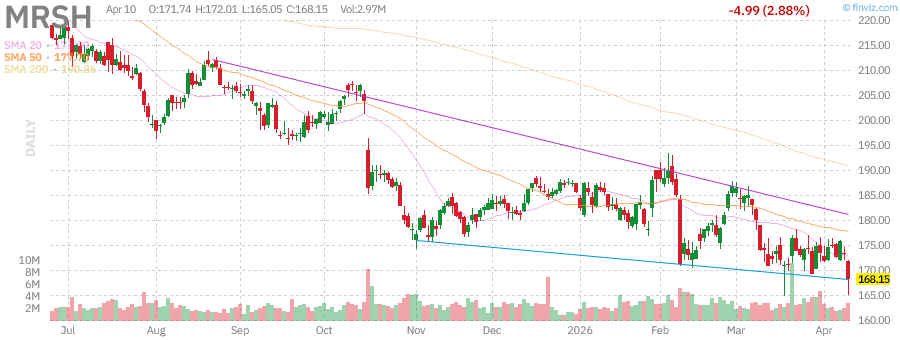

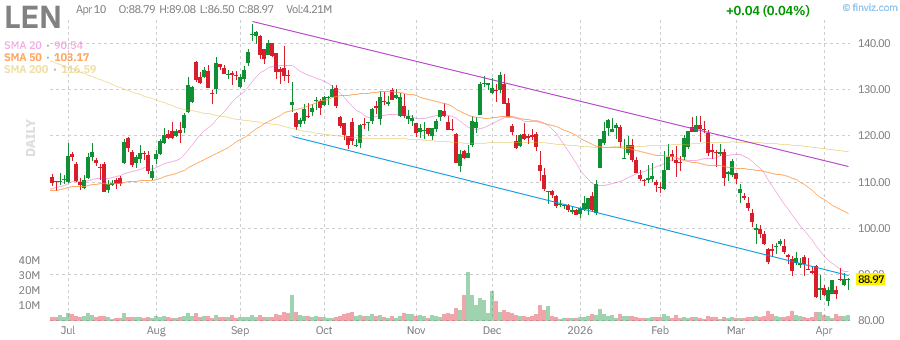

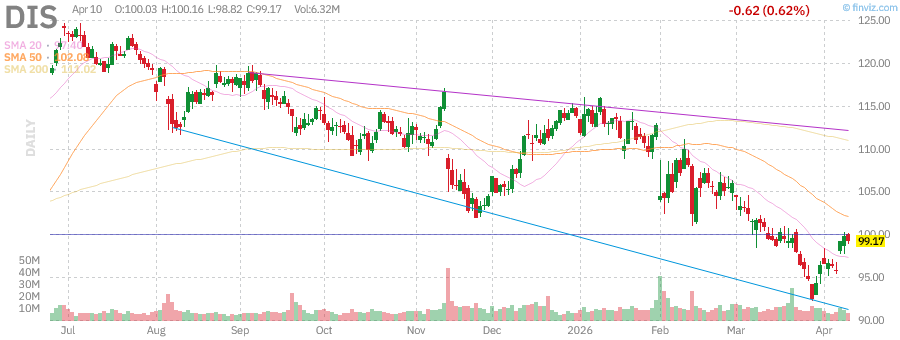

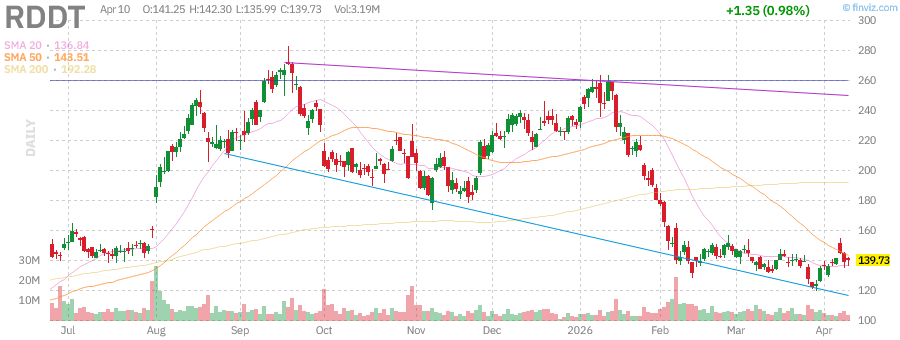

In [ ]:
# --- chart printing ---
from pathlib import Path
from IPython.display import Image, display

output_dir = Path('asset')
output_dir.mkdir(parents=True, exist_ok=True)

failed_chart_tickers = []

for ticker in df.symbol.dropna().unique():
    try:
        stock_obj = finvizfinance(ticker)
        stock_obj.ticker_charts(out_dir=str(output_dir))
        plot_volume_profile(ticker)
        plot_volume_profile_10y_5y(ticker)

        candidate_paths = [
            output_dir / f'{ticker}.jpg',
            output_dir / f'{ticker}.jpeg',
            Path(f'{ticker}.jpg'),
            Path(f'{ticker}.jpeg'),
        ]
        image_path = next((p for p in candidate_paths if p.exists()), None)

        if image_path is not None:
            display(Image(filename=str(image_path)))
        else:
            failed_chart_tickers.append(ticker)
    except Exception:
        failed_chart_tickers.append(ticker)

if failed_chart_tickers:
    print('Chart image not available for:')
    print(failed_chart_tickers)